##Системы искусственного интеллекта

##ЛР4. Decision Tree
[10 баллов]

## Этапы

Задание состоит в детальном изучении данных и построении модели предсказания стоимости объекта недвижимости.

Что входит в работу:

*  Загрузка и предобработка данных.
*  Применение и настройка линейных моделей.
*  Применение и настройка решающего дерева.
*  Сравнение моделей.
*  Оценка важности признаков.


-------------

## Задание

Мы будем работать с данными из [датасета](https://www.kaggle.com/datasets/mrdaniilak/russia-real-estate-20182021), в котором содержится информация об объектах недвижимости в России с их стоимостью за 2018-2021 гг.

*   Цена — Цена в рублях РФ (*числовое*)
*   Дата — дата публикации объявления (*временное*)
*   Время — время публикаци объявления (*временное*)
*   Коорданата x — значение координаты (широта) (*числовое*)
*   Коорданата y — значение координаты (долгота) (*числовое*)
*   Номер — код региона РФ (*категориальное*)
*   Тип здания — тип сооружения, в котором находится квартира (*категориальное*)
*   Этаж — номер этажа, на котором находится квартира (*категориальное* или *числовое*?)
*   Число этажей в доме — общее количество этажей в здании (*категориальное* или *числовое*?)
*   Комнаты — количество комнат в квартире, -1 означает студии с открытой планировкой (*категориальное* или *числовое*?)
*   Площадь — общая площадь квартиры в кв. метрах (*числовое*)
*   Площадь кухни — площадь кухни в кв. метрах (*числовое*)
*   Тип квартиры — тип квартиры, где 1 означает вторичный рынок недвижимости, 11 - новостройка (*категориальное*)

<font color='CornflowerBlue'>**Целевой переменной (target, y)**</font> будем считать цену (столбец `price`)

### **0. Загружаем данные**

In [22]:
# ! gdown 13swGEWvhO4iurSN8Rddap4AHo1pAAljMl
# ! unzip 'rus_real_estate.zip'

In [23]:
 # Прописываем путь к папке с файлом
# path = '/content/rus_real_estate.csv'
path = 'rus_real_estate.csv'

In [24]:
region_name = {
    '2661': 'Санкт-Петербург',
    '3446': 'Ленинградская область',
    '3': 'Москва',
    '81': 'Московская область',
    '2843': 'Краснодарский край',
    '2871': 'Нижегородская область',
    '3230': 'Ростовская область',
    '3106': 'Самарская область',
    '2922': 'Республика Татарстан',
    '2900': 'Ставропольский край',
    '2722': 'Республика Башкортостан',
    '6171': 'Свердловская область',
    '4417': 'Республика Коми',
    '5282': 'Челябинская область',
    '5368': 'Иркутская область',
    '5520': 'Пермский край',
    '6817': 'Алтайский край',
    '9579': 'Республика Бурятия',
    '2604': 'Ярославская область',
    '1010': 'Удмуртская Республика',
    '7793': 'Псковская область',
    '13919': 'Республика Северная Осетия — Алания',
    '2860': 'Кемеровская область',
    '3019': 'Чувашская Республика',
    '4982': 'Республика Марий Эл',
    '9648': 'Кабардино-Балкарская Республика',
    '5241': 'Республика Мордовия',
    '3870': 'Красноярский край',
    '3991': 'Тюменская область',
    '2359': 'Республика Хакасия',
    '9654': 'Новосибирская область',
    '2072': 'Воронежская область',
    '8090': 'Республика Карелия',
    '4007': 'Республика Дагестан',
    '11171': 'Республика Саха (Якутия)',
    '10160': 'Забайкальский край',
    '7873, 6937': 'Республика Крым',
    '2594': 'Кировская область',
    '8509': 'Республика Калмыкия',
    '11416': 'Республика Адыгея',
    '11991': 'Карачаево-Черкесская Республика',
    '5178': 'Республика Тыва',
    '13913': 'Республика Ингушетия',
    '6309': 'Республика Алтай',
    '5952': 'Белгородская область',
    '6543': 'Архангельская область',
    '2880': 'Тверская область',
    '5993': 'Пензенская область',
    '2484': 'Ханты-Мансийский автономный округ',
    '4240': 'Липецкая область',
    '5789': 'Владимирская область',
    '14880': 'Ямало-Ненецкий автономный округ',
    '1491': 'Рязанская область',
    '2885': 'Чеченская Республика',
    '5794': 'Смоленская область',
    '2528': 'Саратовская область',
    '4374': 'Вологодская область',
    '4695': 'Волгоградская область',
    '2328': 'Калужская область',
    '5143': 'Тульская область',
    '2806': 'Тамбовская область',
    '14368': 'Мурманская область',
    '5736': 'Новгородская область',
    '7121': 'Курская область',
    '4086': 'Хабаровский край',
    '821': 'Брянская область',
    '10582': 'Астраханская область',
    '7896': 'Калининградская область',
    '8640': 'Омская область',
    '5703': 'Курганская область',
    '10201': 'Томская область',
    '4249': 'Ульяновская область',
    '3153': 'Оренбургская область',
    '4189': 'Костромская область',
    '2814': 'Орловская область',
    '13098': 'Камчатский край',
    '8894': 'Ивановская область',
    '7929': 'Амурская область',
    '16705': 'Магаданская область',
    '69': 'Еврейская автономная область',
    '4963': 'Приморский край',
    '1901': 'Сахалинская область',
    '61888': 'Ненецкий автономный округ'
}

### **<font color='DarkOrange'> Задача 1. [1 балл]</font>**

1.Сделайте первичную обработку данных:

1.1. Выберите один любой регион/город, для которого достаточно данных для построения модели, и оставьте выборку только для этого региона/города. Напишите, какой город выбрали

1.2. Удалите некорректные записи и выбросы

1.3. Создайте дополнительную колонку 'year' - год продажи

1.4. Удалите колонки 'date' и 'time'

1.5. Исключите 1% с каждого хвоста распределения по целевой переменной

1.6. Исключите 1% с каждого хвоста распределения по тем переменным, по которым Вам кажется важно это сделать

1.7. Исследуйте, какие еще признаки можно преобразовать различными способами, например, нелинейная трансформация и пр. Выберите такие признаки и преобразуйте их

In [25]:
import pandas as pd
import numpy as np

df = pd.read_csv(path)

print(df['region'].value_counts().head())

df = df[df['region'] == 5368]
print("Выбран регион:", region_name['5368'])

# === 1.2. Удаление некорректных и выбросных значений ===
df = df.dropna(subset=['price', 'area', 'rooms'])
df = df[(df['price'] > 0) & (df['area'] > 0)]

# === 1.3. Создание колонки 'year' ===
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['year'] = df['date'].dt.year

# === 1.4. Удаление ненужных колонок ===
df = df.drop(columns=['date', 'time'], errors='ignore')

# === 1.5. Исключение 1% хвостов по целевой переменной (например, price) ===
low, high = df['price'].quantile([0.01, 0.99])
df = df[(df['price'] >= low) & (df['price'] <= high)]

# === 1.6. Исключение хвостов по важным переменным (например, area, rooms) ===
for col in ['area', 'rooms']:
    low, high = df[col].quantile([0.01, 0.99])
    df = df[(df[col] >= low) & (df[col] <= high)]

# === 1.7. Преобразования признаков ===
# Логарифмируем цену и площадь для нормализации распределения
df['log_price'] = np.log1p(df['price'])
df['log_area'] = np.log1p(df['area'])

if 'building_type' in df.columns:
    df['building_type'] = df['building_type'].astype('category').cat.codes

print(df.info())
print(df.head())


region
9654    1049435
2843     637224
81       500368
2661     461820
3        439511
Name: count, dtype: int64
Выбран регион: Иркутская область
<class 'pandas.core.frame.DataFrame'>
Index: 26630 entries, 45 to 5475949
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          26630 non-null  int64  
 1   geo_lat        26630 non-null  float64
 2   geo_lon        26630 non-null  float64
 3   region         26630 non-null  int64  
 4   building_type  26630 non-null  int8   
 5   level          26630 non-null  int64  
 6   levels         26630 non-null  int64  
 7   rooms          26630 non-null  int64  
 8   area           26630 non-null  float64
 9   kitchen_area   26630 non-null  float64
 10  object_type    26630 non-null  int64  
 11  year           26630 non-null  int32  
 12  log_price      26630 non-null  float64
 13  log_area       26630 non-null  float64
dtypes: float64(6), int32(1), int64(6), int

2.Выведите на экран первые строки изменённой таблицы, чтобы проверить, что все преобразования сработали.

In [26]:
print(df.head(10))
print(df.describe(include='all'))

        price    geo_lat     geo_lon  region  building_type  level  levels  \
45    2350000  52.550984  103.882608    5368              4      1       2   
1464  1250000  52.207428  104.070958    5368              1      4       5   
1501  1400000  52.556659  103.878031    5368              4      1       2   
1502  1300000  56.288383  101.898774    5368              1      5       5   
1505  1880000  52.530949  103.863231    5368              1      6      10   
1511  2000000  56.167199  101.632215    5368              1      3       6   
1547  2200000  52.209488  104.068895    5368              1      1       5   
1570  1550000  52.544879  103.888543    5368              1      2       5   
1590  2650000  56.174974  101.605127    5368              1      3       9   
1613   900000  56.303154  101.753092    5368              3      5       5   

      rooms  area  kitchen_area  object_type  year  log_price  log_area  
45        3  60.0           6.2            1  2018  14.669926  4.11

3. Исследуйте закон распределения целевого признака (напомним, таргетом считаем столбец `price`). Является ли распределение нормальным?

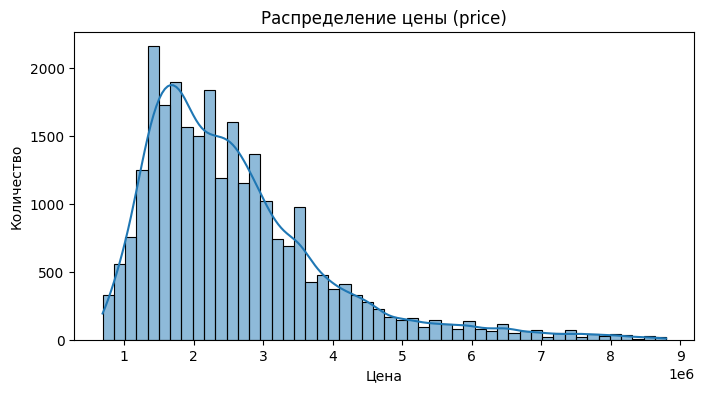

Shapiro-Wilk p-value: 0.00000
D'Agostino K^2 p-value: 0.00000
→ Распределение НЕ является нормальным.


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest

# === 3. Исследуем распределение целевого признака ===
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Распределение цены (price)')
plt.xlabel('Цена')
plt.ylabel('Количество')
plt.show()

stat1, p1 = shapiro(df['price'].sample(5000, random_state=0) if len(df) > 5000 else df['price'])
stat2, p2 = normaltest(df['price'].sample(5000, random_state=0) if len(df) > 5000 else df['price'])

print(f"Shapiro-Wilk p-value: {p1:.5f}")
print(f"D'Agostino K^2 p-value: {p2:.5f}")

if p1 < 0.05 or p2 < 0.05:
    print("→ Распределение НЕ является нормальным.")
else:
    print("→ Распределение можно считать близким к нормальному.")


### **<font color='DarkOrange'> Задача 2. [1 балл]</font>**

Подготовка к обучению

1. Создайте матрицу объект-признак  `X` и вектор с целевой переменной (price) `y`.

In [28]:
# === 4. Подготовка к обучению ===

y = df['price']

X = df.drop(columns=['price', 'log_price'], errors='ignore')

print("Форма X:", X.shape)
print("Форма y:", y.shape)

print(X.head())
print(y.head())


Форма X: (26630, 12)
Форма y: (26630,)
        geo_lat     geo_lon  region  building_type  level  levels  rooms  \
45    52.550984  103.882608    5368              4      1       2      3   
1464  52.207428  104.070958    5368              1      4       5      1   
1501  52.556659  103.878031    5368              4      1       2      2   
1502  56.288383  101.898774    5368              1      5       5      3   
1505  52.530949  103.863231    5368              1      6      10      2   

      area  kitchen_area  object_type  year  log_area  
45    60.0           6.2            1  2018  4.110874  
1464  31.0           6.6            1  2018  3.465736  
1501  45.0           6.0            1  2018  3.828641  
1502  64.0           9.0            1  2018  4.174387  
1505  48.0           9.0            1  2018  3.891820  
45      2350000
1464    1250000
1501    1400000
1502    1300000
1505    1880000
Name: price, dtype: int64



2. Разбейте данные на тренировочную и тестовую части, размер тестовой части — 30%.


In [29]:
from sklearn.model_selection import train_test_split

# === 5. Разделение данных ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # 30% данных — тест
    random_state=42,    # для воспроизводимости
    shuffle=True
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (18641, 12)
Размер тестовой выборки: (7989, 12)


3. Для линейных моделей важно применить нормализацию, возьмем StandardScaler, обучим метод на тренировочных данных и применим его и к трейну, и к тесту.

In [30]:
from sklearn.preprocessing import StandardScaler

# === 6. Нормализация признаков ===
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Масштабированные признаки:")
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Масштабированные признаки:
Train shape: (18641, 12)
Test shape: (7989, 12)


4. После масштабирования признаков `X_train` и `X_test` перестали быть объектами типа `pd.DataFrame`, это неудобно. Приведите их снова к `pd.DataFrame`.

In [31]:
# === 7. Преобразуем обратно в DataFrame ===
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled,  columns=X_test.columns,  index=X_test.index)

print(type(X_train))
print(X_train.head())


<class 'pandas.core.frame.DataFrame'>
          geo_lat   geo_lon  region  building_type     level    levels  \
2062549 -0.483296  0.311623     0.0      -0.755640  0.042138 -0.434609   
1879634 -0.479209  0.307143     0.0      -0.755640 -0.302830 -0.434609   
4070750 -0.626531  0.700493     0.0       1.148372 -0.302830 -0.434609   
1390312 -0.622997  0.629942     0.0       1.148372  0.387106  0.632718   
3155123 -0.476351  0.308508     0.0      -0.755640 -0.647799 -0.434609   

            rooms      area  kitchen_area  object_type      year  log_area  
2062549 -0.007714  0.051221      0.047269    -0.286826 -0.437429  0.197995  
1879634 -0.007714 -0.349316     -0.608158    -0.286826 -0.437429 -0.232147  
4070750 -1.088919 -1.065030     -0.171207    -0.286826  0.699191 -1.166330  
1390312  1.073491  1.292228     -0.171207    -0.286826 -0.437429  1.267154  
3155123 -0.007714 -0.611964      3.783202    -0.286826  0.699191 -0.546391  


### **<font color='DarkOrange'> Задача 3. [1 балл]</font>**

Обучите на тренировочных данных с параметрами по умолчанию:

1) линейную регрессию Ridge;

2) метод опорных векторов [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) (с kernel='linear').

<font color='OrangeRed'>**Важно!**</font> SVR может долго обучаться без нормализации данных, возьмите на заметку

In [32]:
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# === 8. Обучение моделей ===

ridge = Ridge()
ridge.fit(X_train, y_train)

Ridge()

In [33]:
from sklearn.svm import LinearSVR

svr = LinearSVR(random_state=42)

svr.fit(X_train, y_train)
print("Модели успешно обучены.")

Модели успешно обучены.


In [34]:
# from google.colab import drive
# drive.mount('/content/drive')

3) С помощью обученных моделей сделайте предсказание на тестовых данных. Вычислите значение метрики [RMSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) на тесте.

In [35]:
from sklearn.metrics import mean_squared_error
import numpy as np

# === 9. Предсказания и оценка качества ===
y_pred_ridge = ridge.predict(X_test)
y_pred_svr = svr.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

print(f"RMSE Ridge: {rmse_ridge:.2f}")
print(f"RMSE SVR (linear): {rmse_svr:.2f}")


RMSE Ridge: 758492.24
RMSE SVR (linear): 2903556.86


### **<font color='DarkOrange'> Задача 4. [2 баллa]</font>**

Обучите [решающее дерево](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn-tree-decisiontreeregressor) с параметрами по умолчанию на тренировочных данных, сделайте предсказание на тесте и вычислите на тесте RMSE

In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# === 10. Решающее дерево ===
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
print(f"RMSE DecisionTree: {rmse_tree:.2f}")


RMSE DecisionTree: 652317.83


Нужно ли масшабировать признаки для обучения решающего дерева? Проверьте это, заново разбив данные на тренировочную и тестовую части (назовите новые полученные объекты новыми названиями), и проведите обучение, предсказание и оценку метрики до масштабирования и после.

<font color='LightSteelBlue'>**Подсказка:**</font> Можно использовать любой метод мастшабирования признаков

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# === 11. Разделим данные заново ===
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

tree_no_scaler = DecisionTreeRegressor(random_state=42)
tree_no_scaler.fit(X_train2, y_train2)
y_pred_no_scaler = tree_no_scaler.predict(X_test2)
rmse_no_scaler = np.sqrt(mean_squared_error(y_test2, y_pred_no_scaler))

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

tree_with_scaler = DecisionTreeRegressor(random_state=42)
tree_with_scaler.fit(X_train2_scaled, y_train2)
y_pred_with_scaler = tree_with_scaler.predict(X_test2_scaled)
rmse_with_scaler = np.sqrt(mean_squared_error(y_test2, y_pred_with_scaler))

print(f"RMSE без масштабирования: {rmse_no_scaler:.2f}")
print(f"RMSE с масштабированием:  {rmse_with_scaler:.2f}")


RMSE без масштабирования: 645723.30
RMSE с масштабированием:  652317.83


Какой вывод про масштабирование признаков для обучения дерева можно сделать?

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

В ходе эксперимента было проведено сравнение качества модели решающего дерева до и после масштабирования признаков. Значение RMSE без масштабирования составило 645 723.30, а с масштабированием — 652 317.83. Таким образом, масштабирование признаков не только не улучшило качество модели, но даже незначительно его ухудшило. Это подтверждает, что для решающих деревьев масштабирование признаков не является необходимым этапом предобработки данных.

Дерево решений выбирает признаки, разбивая пространство по порогам значений вида (x_j < threshold), а не вычисляя расстояния между объектами, в отличие от таких алгоритмов, как SVM, kNN и линейные модели. Поэтому изменение масштаба признаков не влияет на порядок сравнений и, следовательно, не оказывает положительного влияния на структуру дерева и точность модели.

### **<font color='DarkOrange'> Задача 5. [3 баллa]</font>**

Теперь ваша цель — максимально улучшить модели

Для этого:

1) у линейных моделей:
  * `SVR` (если смогли обучить модель) - подберите гиперпараметр `С` (переберите $20$ значений `C` в диапазоне от $0.1$ до $10$ с равным шагом);
  * `Ridge` - подберите гиперпараметр $\alpha$ (переберите $20$ значений $\alpha$ в диапазоне от $10^{-3}$ до $10^{3}$ с равным логарифмическим шагом)

2) у решающего дерева подберите `max_depth` (переберите глубину от $1$ до $10$ с шагом $1$) и `criterion` — `squared_error` или `absolute_error` (см. [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html#sklearn-tree-decisiontreeregressor)).

Для подбора параметров используйте [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) с `5` фолдами и метрикой `r2`.

**<font color='OrangeRed'> Важно! </font>** Подбор параметров осуществляется только по тренировочным данным! Контролируйте свои пайплайны обучения на предмет ликов!

In [38]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.svm import LinearSVR
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# === 12. Подбор гиперпараметров ===

ridge_params = {'alpha': np.logspace(-3, 3, 20)}
ridge_grid = GridSearchCV(
    Ridge(), ridge_params, cv=5, scoring='r2', n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
print("Лучший Ridge alpha:", ridge_grid.best_params_)
print("R² Ridge (train CV):", ridge_grid.best_score_)

svr_params = {'C': np.linspace(0.1, 10, 20)}
svr_grid = GridSearchCV(
    LinearSVR(random_state=42, max_iter=5000),
    svr_params, cv=5, scoring='r2', n_jobs=-1
)
svr_grid.fit(X_train, y_train)
print("Лучший LinearSVR C:", svr_grid.best_params_)
print("R² LinearSVR (train CV):", svr_grid.best_score_)

tree_params = {
    'max_depth': range(1, 11),
    'criterion': ['squared_error', 'absolute_error']
}
tree_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    tree_params, cv=5, scoring='r2', n_jobs=-1
)
tree_grid.fit(X_train, y_train)
print("Лучшие параметры дерева:", tree_grid.best_params_)
print("R² дерева (train CV):", tree_grid.best_score_)

from sklearn.metrics import mean_squared_error, r2_score

models = {
    'Ridge': ridge_grid.best_estimator_,
    'LinearSVR': svr_grid.best_estimator_,
    'DecisionTree': tree_grid.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"\n{name}: RMSE={rmse:.2f}, R²={r2:.3f}")


Лучший Ridge alpha: {'alpha': np.float64(0.3359818286283781)}
R² Ridge (train CV): 0.671705623482861
Лучший LinearSVR C: {'C': np.float64(10.0)}
R² LinearSVR (train CV): -3.498712901886145
Лучшие параметры дерева: {'criterion': 'squared_error', 'max_depth': 9}
R² дерева (train CV): 0.8138027177787513

Ridge: RMSE=758484.39, R²=0.677

LinearSVR: RMSE=2755631.13, R²=-3.265

DecisionTree: RMSE=581769.99, R²=0.810


3) После подбора гиперпараметров обучите модели с найденными гиперпараметрами на тренировочных данных, сделайте предсказания на тесте и оцените их качество (`RMSE`).

In [39]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import numpy as np

# лучшие модели из GridSearchCV
best_ridge = ridge_grid.best_estimator_
best_svr = svr_grid.best_estimator_
best_tree = tree_grid.best_estimator_

metrics = {}

for name, model in {
    'Ridge': best_ridge,
    'LinearSVR': best_svr,
    'DecisionTree': best_tree
}.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    metrics[name] = rmse

# создаём таблицу
df_results = pd.DataFrame({
    'Model': metrics.keys(),
    'RMSE': metrics.values()
}).sort_values(by='RMSE')

print(df_results)

# вывод лучшей модели
best_model = df_results.iloc[0]
print("\nЛучшая модель по RMSE:")
print(best_model)



          Model          RMSE
2  DecisionTree  5.817700e+05
0         Ridge  7.584844e+05
1     LinearSVR  2.755631e+06

Лучшая модель по RMSE:
Model     DecisionTree
RMSE     581769.990794
Name: 2, dtype: object


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

По результатам экспериментов наилучшее качество предсказания стоимости недвижимости показала модель DecisionTree. Для неё значение RMSE составило 581 769.99, а коэффициент детерминации R² = 0.810, что свидетельствует о высокой точности предсказаний и хорошей способности модели объяснять вариацию целевой переменной.

Модель Ridge-регрессии продемонстрировала более слабый результат по сравнению с деревом решений: RMSE = 758 484.39, R² = 0.677. Несмотря на использование регуляризации и достаточно стабильную работу, линейная модель оказалась менее точной из-за того, что зависимость между признаками и ценой имеет выраженный нелинейный характер.

Наихудшие результаты показала модель LinearSVR: RMSE = 2 755 631.13, R² = –3.265, что указывает на её полную неэффективность для данной задачи. Это связано с высокой чувствительностью метода к шуму и тем, что данные плохо описываются линейной разделяющей поверхностью.

Итог: на данном этапе модель DecisionTree является лучшей среди всех протестированных алгоритмов и обеспечивает наиболее точные предсказания стоимости недвижимости.

### **<font color='DarkOrange'> Задача 6. [1 балл]</font>**

Постройте диаграммы (горизонтальные бары) важности признаков для линейной регрессии и дерева (для линейных моделей берите модуль значений весов). Сравните между собой списки из трёх самых важных признаков. Совпадают ли они?

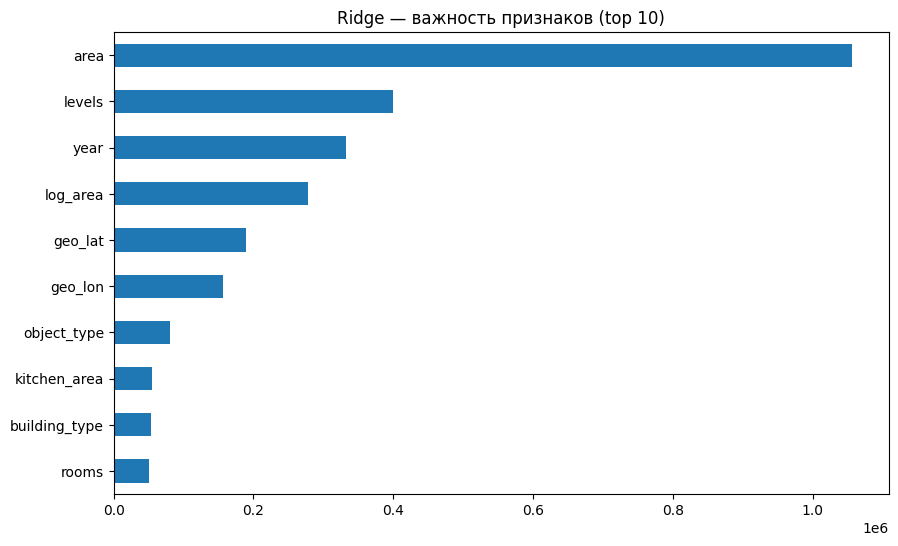

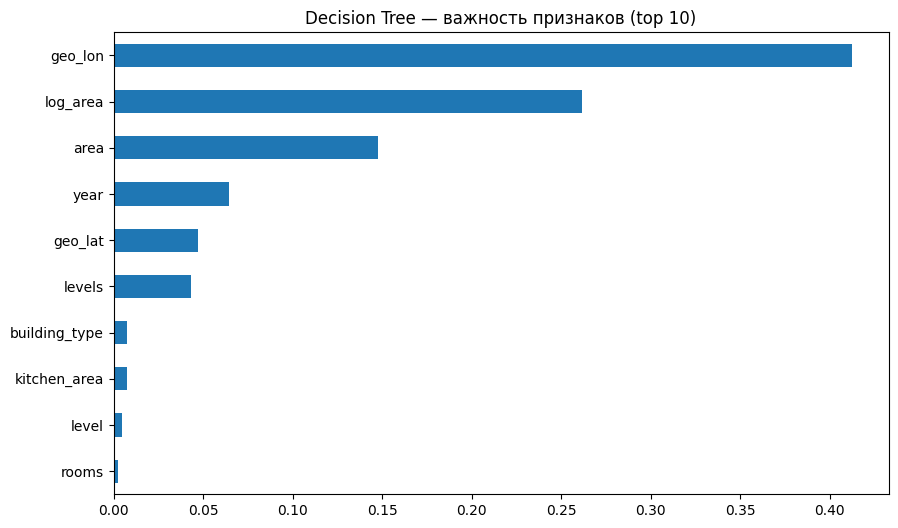

Top-3 Ridge:
area      1.055970e+06
levels    4.002417e+05
year      3.327763e+05
dtype: float64

Top-3 Decision Tree:
geo_lon     0.412204
log_area    0.261553
area        0.147877
dtype: float64


In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. Важности Ridge (берём абсолютные коэффициенты) ---
ridge_importance = pd.Series(
    np.abs(best_ridge.coef_),
    index=X_train.columns
).sort_values(ascending=False)

# --- 2. Важности дерева ---
tree_importance = pd.Series(
    best_tree.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# --- 3. Графики ---
plt.figure(figsize=(10, 6))
ridge_importance.head(10).plot(kind='barh')
plt.title("Ridge — важность признаков (top 10)")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(10, 6))
tree_importance.head(10).plot(kind='barh')
plt.title("Decision Tree — важность признаков (top 10)")
plt.gca().invert_yaxis()
plt.show()

# --- 4. Печатаем топ-3 ---
print("Top-3 Ridge:")
print(ridge_importance.head(3))

print("\nTop-3 Decision Tree:")
print(tree_importance.head(3))


<font color='MediumOrchid'>**Ваши выводы тут:**</font>

У обеих моделей среди наиболее значимых признаков присутствует area (общая площадь квартиры) — это ожидаемо, так как именно площадь является одним из ключевых факторов, напрямую влияющих на стоимость недвижимости. Однако далее приоритеты моделей существенно различаются.

Ridge-регрессия выделяет следующие наиболее важные признаки:

area — 1.06 · 10⁶

levels — 4.00 · 10⁵

year — 3.33 · 10⁵

Это указывает на то, что Ridge опирается на глобальные линейные зависимости: цена увеличивается с ростом площади, этажности здания и года постройки. Модель преимущественно использует общие числовые характеристики объекта.

Решающее дерево выделяет следующие наиболее значимые признаки:

geo_lon — 0.412

log_area — 0.262

area — 0.148

В отличие от Ridge, дерево в первую очередь ориентируется на пространственное положение объекта (долгота — geo_lon), а также на логарифм площади, что позволяет лучше учитывать локальные особенности распределения цен по районам. Это связано с тем, что дерево выбирает признаки, которые обеспечивают наилучшее разбиение данных на подмножества.


##Итоговый вывод

Общим ключевым признаком для обеих моделей является area.

Ridge-регрессия делает акцент на глобальных линейных числовых характеристиках (площадь, этажность, год постройки).

DecisionTree в большей степени опирается на пространственные признаки (geo_lon) и нелинейные преобразования площади (log_area), что позволяет лучше учитывать локальную структуру рынка недвижимости.

Это подтверждает, что:

линейные модели ориентируются на общую линейную структуру данных,

деревья решений выявляют локальные нелинейные зависимости и территориальные эффекты.

### **<font color='DarkOrange'> Задача 7. [1 балл]</font>**

Сделайте выводы по самой лучшей модели:

1. Какая модель после подбора гиперпараметров лучше всего решает задачу с точки зрения метрики RMSE?

2. Достаточное ли качество получившейся модели? Можно ли ее использовать в проде?

3. Как можно еще улучшить получившуюся модель? Как в случае линейной модели, так и для дерева.

<font color='MediumOrchid'>**Ваши выводы тут:**</font>

## 1
По результатам подбора гиперпараметров лучшей моделью по метрике RMSE стала DecisionTree
(RMSE ≈ 581 тыс. руб., R² ≈ 0.81), что лучше Ridge и значительно лучше LinearSVR.

## 2
Полученное качество можно считать достаточным для аналитических задач (оценка рынка, предварительный прогноз),
однако для продакшена модель использовать нежелательно, так как ошибка порядка 0.5–0.6 млн рублей всё ещё слишком велика для точной оценки стоимости недвижимости.

## 3
Улучшение модели:

для линейных моделей: логарифмирование таргета, добавление географических и ценовых признаков, переход на ElasticNet;

для деревьев: использование ансамблей (Random Forest, Gradient Boosting, CatBoost), увеличение глубины с контролем переобучения;

общие меры: больше данных и более глубокий feature engineering.